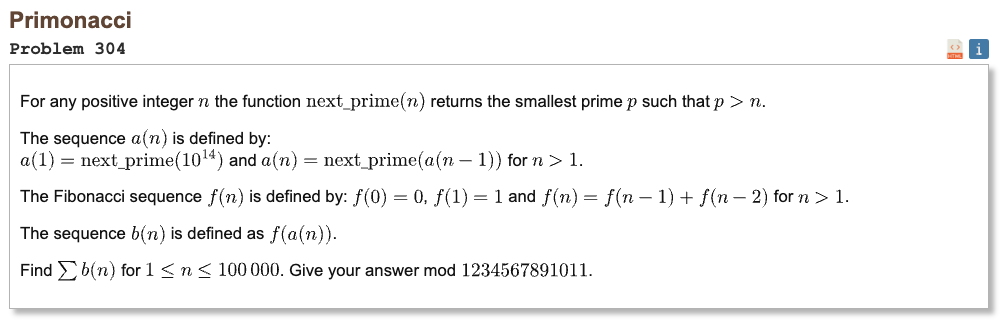

## Initial approach

* first find the first 100000 primes after ten to the fourteenth, and the practical way is a segmented sieve over a window just above that start point
* once those primes are known, the task becomes adding Fibonacci values at those prime positions under the given modulus
* computing each Fibonacci value from scratch would work, but it is cleaner to compute the first one once and then jump forward by the small prime gaps
* use fast doubling to get the Fibonacci pair for any jump size quickly, then combine that jump with the current pair

In [1]:
from math import isqrt

MOD = 1234567891011
START = 10**14
NEED = 100000

def simple_sieve(limit):
    sieve = bytearray(b"\x01") * (limit + 1)
    sieve[0:2] = b"\x00\x00"
    for p in range(2, isqrt(limit) + 1):
        if sieve[p]:
            step_count = ((limit - p * p) // p) + 1
            sieve[p * p : limit + 1 : p] = b"\x00" * step_count
    return [i for i in range(2, limit + 1) if sieve[i]]

def next_primes_after(start, need):
    block = 5_000_000
    base_primes = simple_sieve(isqrt(start + block) + 100)
    primes = []
    low = start + 1

    if low % 2 == 0:
        low += 1

    while len(primes) < need:
        high = low + block - 1
        size = high - low + 1
        sieve = bytearray(b"\x01") * size

        for p in base_primes:
            pp = p * p
            if pp > high:
                break
            first = max(pp, ((low + p - 1) // p) * p)
            for x in range(first, high + 1, p):
                sieve[x - low] = 0

        for i, ok in enumerate(sieve):
            if ok:
                n = low + i
                if n >= 2:
                    primes.append(n)
                    if len(primes) == need:
                        return primes

        low = high + 1

def fib_pair(n, mod):
    if n == 0:
        return 0, 1
    a, b = fib_pair(n >> 1, mod)
    c = (a * ((2 * b - a) % mod)) % mod
    d = (a * a + b * b) % mod
    if n & 1:
        return d, (c + d) % mod
    return c, d

def advance_pair(fn, fn1, step, mod):
    fs, fs1 = fib_pair(step, mod)
    fs_minus_1 = (fs1 - fs) % mod
    new_fn = (fn * fs_minus_1 + fn1 * fs) % mod
    new_fn1 = (fn * fs + fn1 * fs1) % mod
    return new_fn, new_fn1

def solve():
    primes = next_primes_after(START, NEED)

    f, f1 = fib_pair(primes[0], MOD)
    total = f

    for i in range(1, len(primes)):
        gap = primes[i] - primes[i - 1]
        f, f1 = advance_pair(f, f1, gap, MOD)
        total = (total + f) % MOD

    return total

In [2]:
%%time
result = solve()
print("Result:", result)

Result: 283988410192
CPU times: user 1.13 s, sys: 21.1 ms, total: 1.16 s
Wall time: 1.16 s
